<a href="https://colab.research.google.com/github/sabrinazada/forecasting-tax-revenue/blob/main/forecasting_tax_revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

upload world_bank_data_2025.csv


Saving world_bank_data_2025.csv to world_bank_data_2025 (5).csv
dataset loaded. shape: (3472, 16)
proxy dataset shape: (16, 16)
detected columns:
Government Revenue (% of GDP) GDP (Current USD) Inflation (CPI %) Unemployment Rate (%) year
missing values before cleaning:
year          0
tax_rev       2
gdp_growth    2
inflation     1
unemp         1
dtype: int64
missing values after cleaning:
year          0
tax_rev       0
gdp_growth    0
inflation     0
unemp         0
dtype: int64
stationarity test
ADF log_tax: stat=-1.7801, p-value=0.3904
ADF d_log_tax: stat=-3.2046, p-value=0.0197
differencing order: 1
check nan in exogenous
scaled_gdp_growth    0
scaled_inflation     0
scaled_unemp         0
dtype: int64


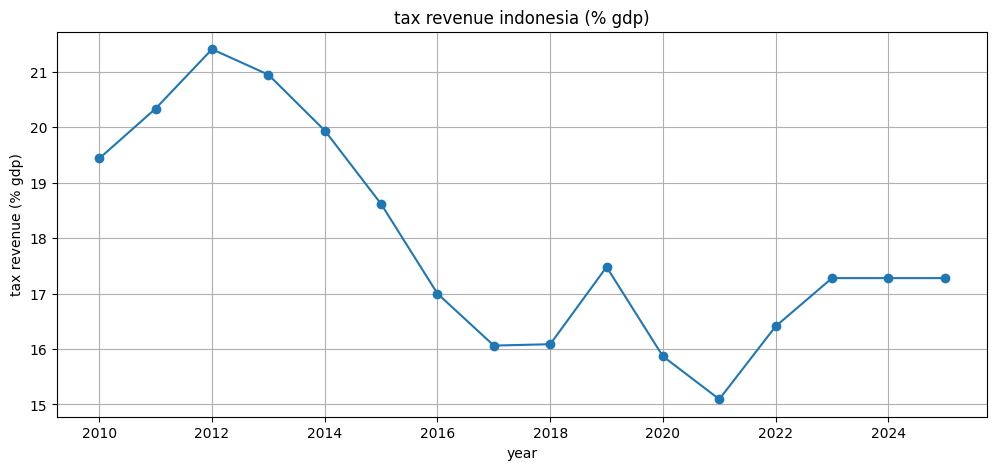

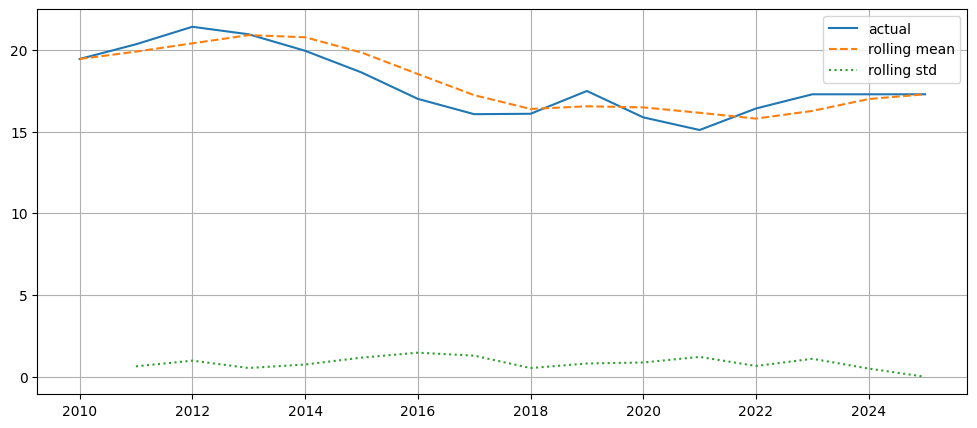

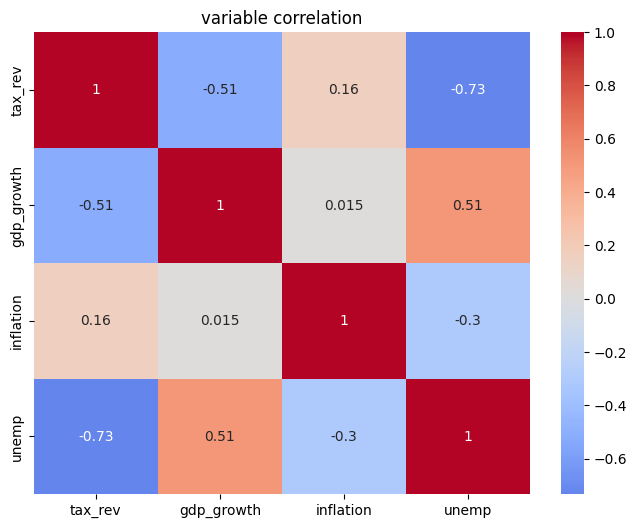

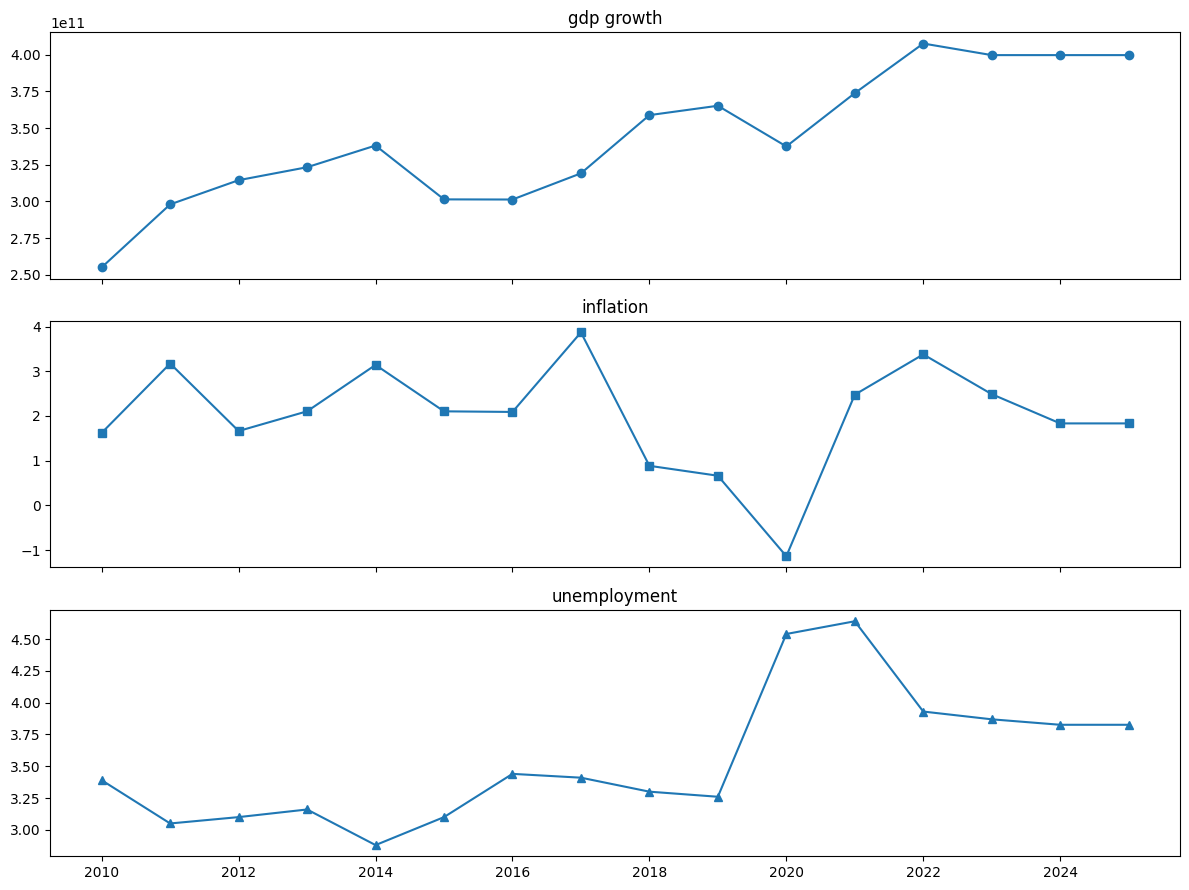

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-23.408, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-21.761, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-25.407, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.232 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   13
Model:               SARIMAX(0, 1, 0)   Log Likelihood                  13.704
Date:                Sat, 07 Mar 2026   AIC                            -25.407
Time:                        15:58:05   BIC                            -24.923
Sample:                             0   HQIC                           -25.587
                                 - 13                                         
Covariance

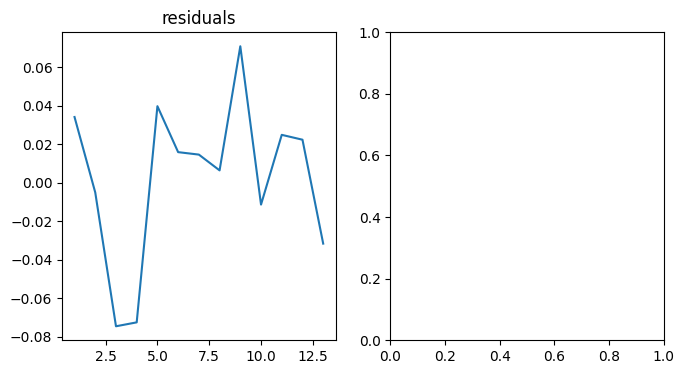

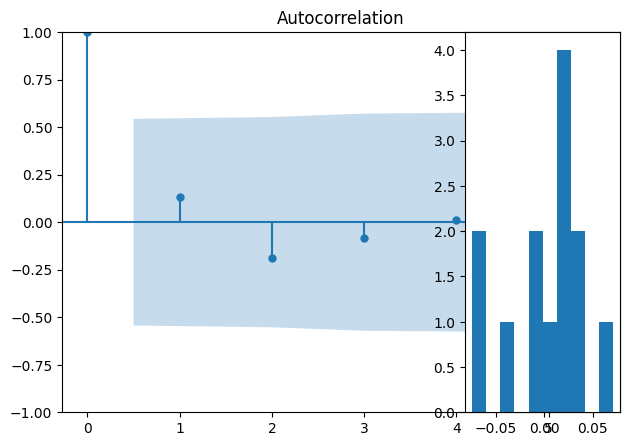

ljung box pvalue: 0.7756660430607858
jarque bera pvalue: 0.6737267651402197


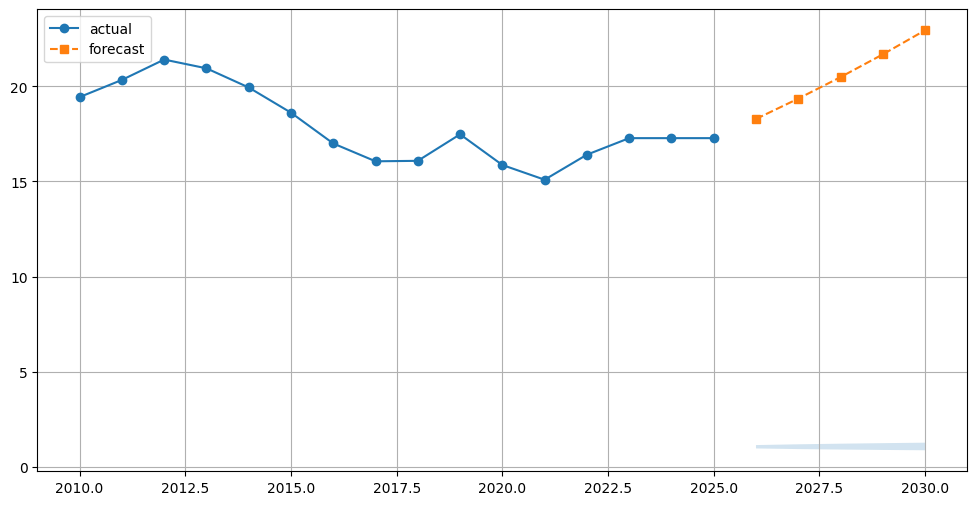

   year   forecast  lower_ci  upper_ci
0  2026  18.286527  0.973211  1.150999
1  2027  19.354072  0.939974  1.191699
2  2028  20.483939  0.915242  1.223902
3  2029  21.679766  0.894898  1.251725
4  2030  22.945404  0.877349  1.276762
mae: 1.5424329654321394
mape: 8.927218799005283
rmse: 1.6321802814229422


In [ ]:
# tax revenue forecasting indonesia

# install and import library
!pip install pmdarima -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
import warnings
warnings.filterwarnings('ignore')


# data
from google.colab import files
print("upload world_bank_data_2025.csv")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print("dataset loaded. shape:", df.shape)


# filter country data
country_mask = df['country_name'].str.contains('malaysia', case=False, na=False)
df_country = df[country_mask].copy()

if len(df_country) == 0:
    fallback_mask = df['country_name'].str.contains('thailand', case=False, na=False)
    df_country = df[fallback_mask].copy()

df_country['country_name'] = 'Indonesia'
df_id = df_country

print("proxy dataset shape:", df_id.shape)


# column detection
def find_col(keywords, df):
    for col in df.columns:
        if any(k in col.lower() for k in keywords):
            return col
    return None

tax_col = find_col(['tax','revenue'], df_id)
gdp_col = find_col(['gdp','growth'], df_id)
inf_col = find_col(['inflation','cpi'], df_id)
unemp_col = find_col(['unemployment'], df_id)
year_col = find_col(['year'], df_id)

if not all([tax_col, gdp_col, inf_col, unemp_col, year_col]):
    raise ValueError("required columns not found")

print("detected columns:")
print(tax_col, gdp_col, inf_col, unemp_col, year_col)

df_id = df_id[[year_col, tax_col, gdp_col, inf_col, unemp_col]].copy()
df_id.columns = ['year','tax_rev','gdp_growth','inflation','unemp']

df_id['year'] = pd.to_numeric(df_id['year'], errors='coerce')
df_id = df_id.sort_values('year').reset_index(drop=True)


# cleaning
print("missing values before cleaning:")
print(df_id.isnull().sum())

df_id = df_id.interpolate(method='linear', limit_direction='both')
df_id = df_id.fillna(method='ffill').fillna(method='bfill')

print("missing values after cleaning:")
print(df_id.isnull().sum())


# transformation
df_id['log_tax'] = np.log(df_id['tax_rev'])

def adf_test(series,name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF {name}: stat={result[0]:.4f}, p-value={result[1]:.4f}")
    return result[1]

print("stationarity test")
p_log = adf_test(df_id['log_tax'],'log_tax')

if p_log >= 0.05:
    df_id['d_log_tax'] = df_id['log_tax'].diff()
    p_diff = adf_test(df_id['d_log_tax'],'d_log_tax')

    if p_diff >= 0.05:
        df_id['d2_log_tax'] = df_id['d_log_tax'].diff()
        adf_test(df_id['d2_log_tax'],'d2_log_tax')
        d = 2
        series_stationary = df_id['d2_log_tax'].dropna()
    else:
        d = 1
        series_stationary = df_id['d_log_tax'].dropna()
else:
    d = 0
    series_stationary = df_id['log_tax'].dropna()

print("differencing order:", d)


# exogenous scaling
scaler = StandardScaler()
exog_vars = ['gdp_growth','inflation','unemp']

exog_scaled = scaler.fit_transform(df_id[exog_vars])
exog_scaled = pd.DataFrame(
    exog_scaled,
    columns=[f'scaled_{v}' for v in exog_vars],
    index=df_id.index
)

df_id = pd.concat([df_id, exog_scaled], axis=1)

print("check nan in exogenous")
print(df_id[['scaled_gdp_growth','scaled_inflation','scaled_unemp']].isnull().sum())


# exploratory analysis
%matplotlib inline

plt.figure(figsize=(12,5))
plt.plot(df_id['year'], df_id['tax_rev'], marker='o')
plt.title('tax revenue indonesia (% gdp)')
plt.xlabel('year')
plt.ylabel('tax revenue (% gdp)')
plt.grid(True)
plt.show()


rolling_mean = df_id['tax_rev'].rolling(window=3, min_periods=1).mean()
rolling_std = df_id['tax_rev'].rolling(window=3, min_periods=1).std()

plt.figure(figsize=(12,5))
plt.plot(df_id['year'], df_id['tax_rev'], label='actual')
plt.plot(df_id['year'], rolling_mean, linestyle='--', label='rolling mean')
plt.plot(df_id['year'], rolling_std, linestyle=':', label='rolling std')
plt.legend()
plt.grid(True)
plt.show()


corr_data = df_id[['tax_rev','gdp_growth','inflation','unemp']].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("variable correlation")
plt.show()


fig, axes = plt.subplots(3,1, figsize=(12,9), sharex=True)

axes[0].plot(df_id['year'], df_id['gdp_growth'], marker='o')
axes[0].set_title("gdp growth")

axes[1].plot(df_id['year'], df_id['inflation'], marker='s')
axes[1].set_title("inflation")

axes[2].plot(df_id['year'], df_id['unemp'], marker='^')
axes[2].set_title("unemployment")

plt.tight_layout()
plt.show()


# train test split
train_years = df_id['year'].iloc[:-2]
test_years = df_id['year'].iloc[-2:]

train = df_id[df_id['year'].isin(train_years)].copy()
test = df_id[df_id['year'].isin(test_years)].copy()

if d == 0:
    y_train = train['log_tax']
    y_test = test['log_tax']
elif d == 1:
    y_train = train['d_log_tax'].dropna()
    y_test = test['d_log_tax'].dropna()
else:
    y_train = train['d2_log_tax'].dropna()
    y_test = test['d2_log_tax'].dropna()

exog_train = train[['scaled_gdp_growth','scaled_inflation','scaled_unemp']].loc[y_train.index]
exog_test = test[['scaled_gdp_growth','scaled_inflation','scaled_unemp']].loc[y_test.index]


# auto arima
if len(y_train) >= 5:

    model_auto = auto_arima(
        y_train,
        exogenous=exog_train,
        start_p=0,
        start_q=0,
        max_p=2,
        max_q=2,
        d=d,
        seasonal=False,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )

    print(model_auto.summary())
    order = model_auto.order

    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)
    print(results.summary())


    # residual diagnostics
    resid = results.resid

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.plot(resid)
    plt.title("residuals")

    plt.subplot(1,3,2)
    plot_acf(resid, lags=5)

    plt.subplot(1,3,3)
    plt.hist(resid, bins=10)

    plt.tight_layout()
    plt.show()


    lb_test = acorr_ljungbox(resid, lags=[5], return_df=True)
    print("ljung box pvalue:", lb_test['lb_pvalue'].values[0])

    jb_stat, jb_pvalue, skew, kurt = jarque_bera(resid)
    print("jarque bera pvalue:", jb_pvalue)


    # forecast
    last_year = df_id['year'].max()
    forecast_years = list(range(last_year+1, last_year+6))

    last_exog = df_id[['scaled_gdp_growth','scaled_inflation','scaled_unemp']].iloc[-1].values

    exog_future = pd.DataFrame(
        [last_exog]*len(forecast_years),
        columns=['scaled_gdp_growth','scaled_inflation','scaled_unemp'],
        index=forecast_years
    )

    forecast_result_obj = results.get_forecast(
        steps=len(forecast_years),
        exog=exog_future
    )

    forecast_diff_log = forecast_result_obj.predicted_mean
    forecast_diff_log_ci = forecast_result_obj.conf_int()

    last_log = df_id['log_tax'].iloc[-1]
    forecast_log = last_log + forecast_diff_log.cumsum()

    forecast_level = np.exp(forecast_log)
    forecast_ci_level = np.exp(forecast_diff_log_ci)


    plt.figure(figsize=(12,6))
    plt.plot(df_id['year'], df_id['tax_rev'], marker='o', label='actual')
    plt.plot(forecast_years, forecast_level, marker='s', linestyle='--', label='forecast')

    plt.fill_between(
        forecast_years,
        forecast_ci_level.iloc[:,0],
        forecast_ci_level.iloc[:,1],
        alpha=0.2
    )

    plt.legend()
    plt.grid(True)
    plt.show()


    forecast_result = pd.DataFrame({
        'year':forecast_years,
        'forecast':forecast_level.values,
        'lower_ci':forecast_ci_level.iloc[:,0].values,
        'upper_ci':forecast_ci_level.iloc[:,1].values
    })

    print(forecast_result)


    # evaluation
    if len(y_test) == 2:

        forecast_test_obj = results.get_forecast(steps=2, exog=exog_test)

        pred_diff_log = forecast_test_obj.predicted_mean
        last_log_train = df_id['log_tax'].iloc[y_train.index[-1]]

        pred_log = last_log_train + pred_diff_log.cumsum()
        pred_level = np.exp(pred_log)

        actual_level = test['tax_rev'].values

        mae = mean_absolute_error(actual_level, pred_level)
        mape = mean_absolute_percentage_error(actual_level, pred_level)*100
        rmse = np.sqrt(mean_squared_error(actual_level, pred_level))

        print("mae:", mae)
        print("mape:", mape)
        print("rmse:", rmse)


    forecast_result.to_csv("forecast_tax_revenue_indonesia.csv", index=False)

else:
    print("training data insufficient")